# Upload Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import joblib

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


# Load Cleaned Dataset

In [2]:
df = pd.read_csv("../data/cleaned_online_retail.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (392692, 15)


# Check Dataset

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,Day,Hour,DayOfWeek,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,1,8,Wednesday,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8,Wednesday,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,1,8,Wednesday,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8,Wednesday,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8,Wednesday,2010-12


# Reference Date

In [4]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Reference Date:", reference_date)

Reference Date: 2011-12-10 12:50:00


# Calculate RFM

In [5]:
rfm = df.groupby("CustomerID").agg(
    Recency=(
        "InvoiceDate",
        lambda x: (reference_date - x.max()).days
    ),
    Frequency=(
        "InvoiceNo",
        "nunique"
    ),
    Monetary=(
        "Revenue",
        "sum"
    )
).reset_index()

# View RFM

In [6]:
rfm.head(10)

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
5,12352,36,8,2506.04
6,12353,204,1,89.00
7,12354,232,1,1079.40
8,12355,214,1,459.40
9,12356,23,3,2811.43


# Step 4 — RFM Statistics

In [7]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


# Check Missing Values

In [8]:
rfm.isnull().sum()

CustomerID    0
Recency       0
Frequency     0
Monetary      0
dtype: int64

# Step 5 — RFM Distributions

# Recency

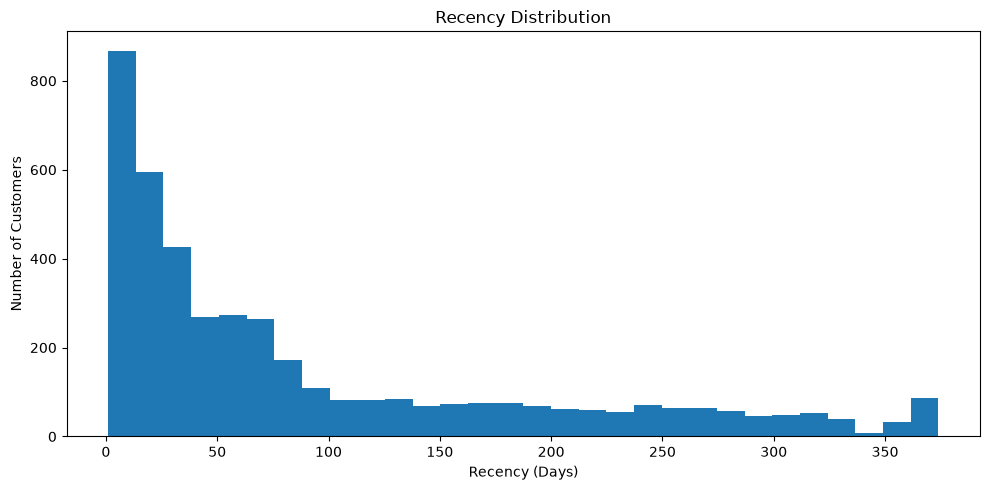

In [10]:
plt.figure(figsize=(10, 5))

plt.hist(
    rfm["Recency"],
    bins=30
)

plt.title("Recency Distribution")
plt.xlabel("Recency (Days)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

# Frequency

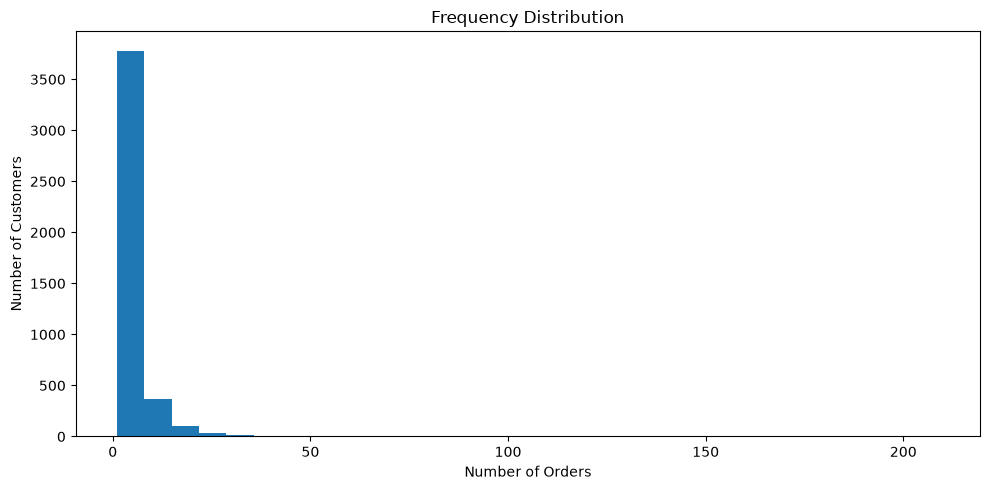

In [11]:
plt.figure(figsize=(10, 5))

plt.hist(
    rfm["Frequency"],
    bins=30
)

plt.title("Frequency Distribution")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

# Monetary

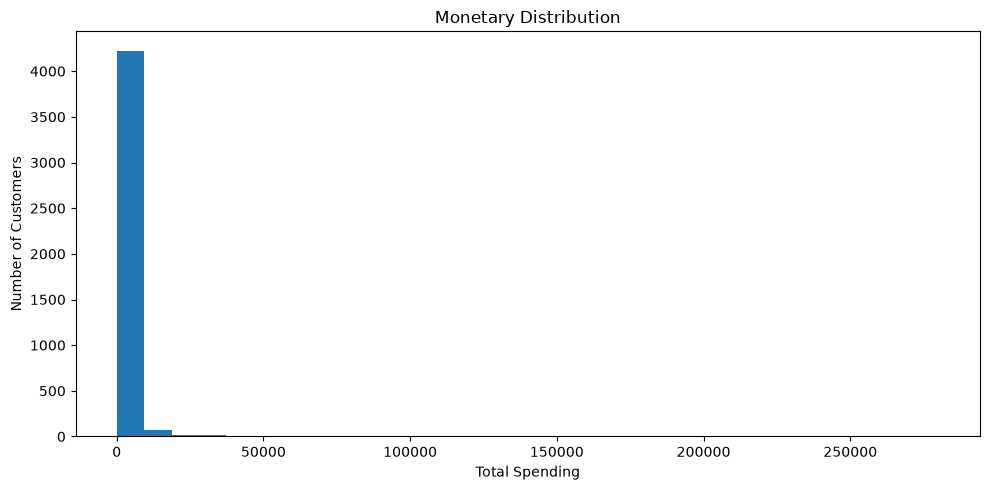

In [12]:
plt.figure(figsize=(10, 5))

plt.hist(
    rfm["Monetary"],
    bins=30
)

plt.title("Monetary Distribution")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

# Step 6 — RFM Skewness

In [13]:
rfm[
    ["Recency", "Frequency", "Monetary"]
].skew()

Recency       1.246048
Frequency    12.067031
Monetary     19.339368
dtype: float64

# Step 7 — Log Transformation

In [14]:
rfm_log = rfm[
    ["Recency", "Frequency", "Monetary"]
].copy()

rfm_log["Recency"] = np.log1p(
    rfm_log["Recency"]
)

rfm_log["Frequency"] = np.log1p(
    rfm_log["Frequency"]
)

rfm_log["Monetary"] = np.log1p(
    rfm_log["Monetary"]
)

rfm_log.head()

,Recency,Frequency,Monetary
0,5.789960,0.693147,11.253955
1,1.098612,2.079442,8.368925
2,4.330733,1.609438,7.494564
3,2.995732,0.693147,7.472245
4,5.739793,0.693147,5.815324


# Step 8 — Scale Features

In [15]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

print("Scaling completed!")

Scaling completed!


# Step 9 — Find Optimal Number of Clusters

In [18]:
inertia = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

# Elbow Plot

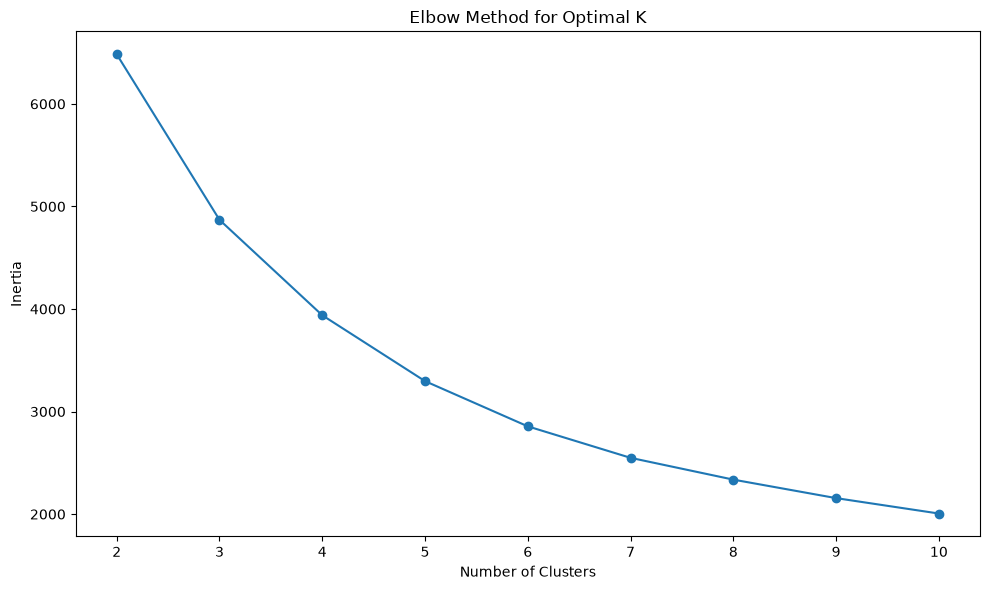

In [19]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.xticks(range(2, 11))

plt.tight_layout()
plt.show()

# Step 10 — Silhouette Score

In [20]:
silhouette_scores = {}

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(
        rfm_scaled,
        labels
    )

    silhouette_scores[k] = score

    print(
        f"K = {k}, "
        f"Silhouette Score = {score:.4f}"
    )

K = 2, Silhouette Score = 0.4328
K = 3, Silhouette Score = 0.3365
K = 4, Silhouette Score = 0.3375
K = 5, Silhouette Score = 0.3162
K = 6, Silhouette Score = 0.3124
K = 7, Silhouette Score = 0.3092
K = 8, Silhouette Score = 0.3033
K = 9, Silhouette Score = 0.2811
K = 10, Silhouette Score = 0.2767


# Step 11 — Select K

In [21]:
optimal_k = 4

# Step 12 — Best K Automatically Find

In [22]:
best_k = max(
    silhouette_scores,
    key=silhouette_scores.get
)

best_score = silhouette_scores[best_k]

print("Best K:", best_k)
print("Best Silhouette Score:", round(best_score, 4))

Best K: 2
Best Silhouette Score: 0.4328


# Step 13— Silhouette Score Visualization

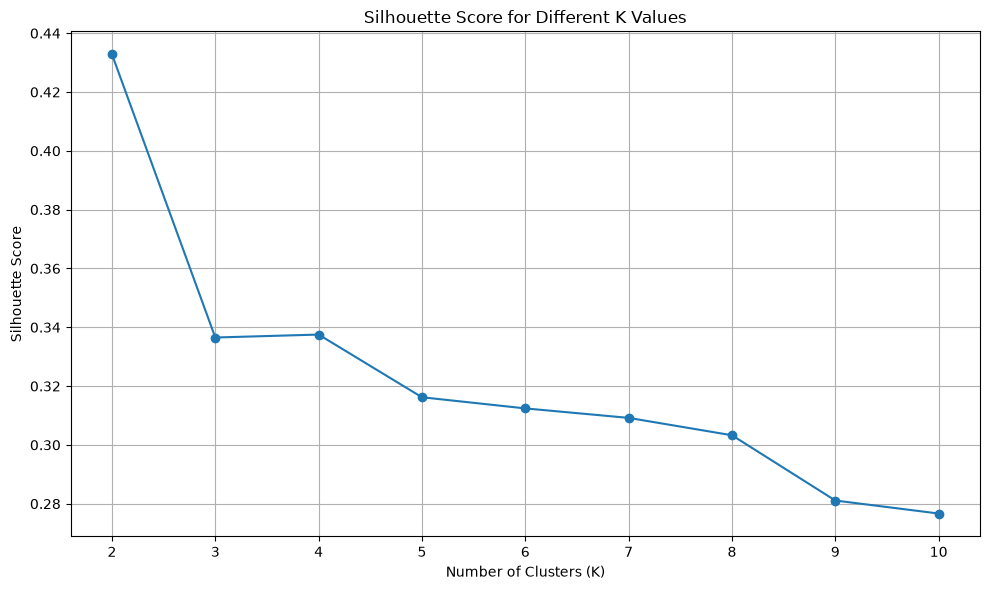

In [23]:
plt.figure(figsize=(10, 6))

plt.plot(
    list(silhouette_scores.keys()),
    list(silhouette_scores.values()),
    marker="o"
)

plt.title("Silhouette Score for Different K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.xticks(range(2, 11))
plt.grid(True)

plt.tight_layout()
plt.show()

# Step 14 — Final K-Means Model

In [24]:
optimal_k = best_k

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print("K-Means model trained successfully!")
print("Number of clusters:", optimal_k)

K-Means model trained successfully!
Number of clusters: 2


# Step 15 — Customer Cluster Count

In [25]:
cluster_counts = (
    rfm["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_counts

Cluster
0    2672
1    1666
Name: count, dtype: int64

# Visualization:

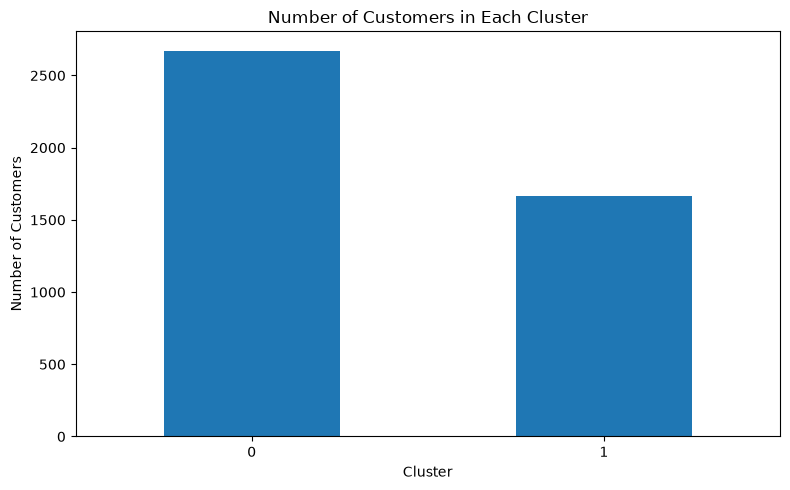

In [27]:
plt.figure(figsize=(8, 5))

cluster_counts.plot(
    kind="bar"
)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Step 16 — Cluster Analysis

In [29]:
cluster_summary = rfm.groupby("Cluster").agg(
    Customers=("CustomerID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).round(2)

cluster_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,2672,134.09,1.67,495.59
1,1666,25.89,8.44,4539.60


# Step 17 — Cluster Visualization

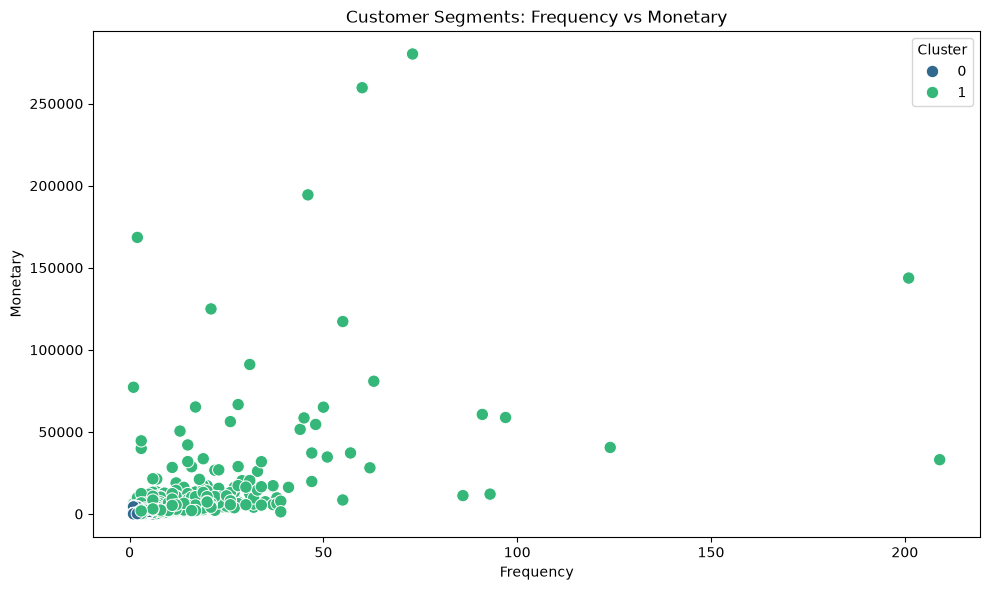

In [30]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="viridis",
    s=80
)

plt.title("Customer Segments: Frequency vs Monetary")
plt.xlabel("Frequency")
plt.ylabel("Monetary")

plt.tight_layout()
plt.show()

# Step 18 — Recency vs Monetary

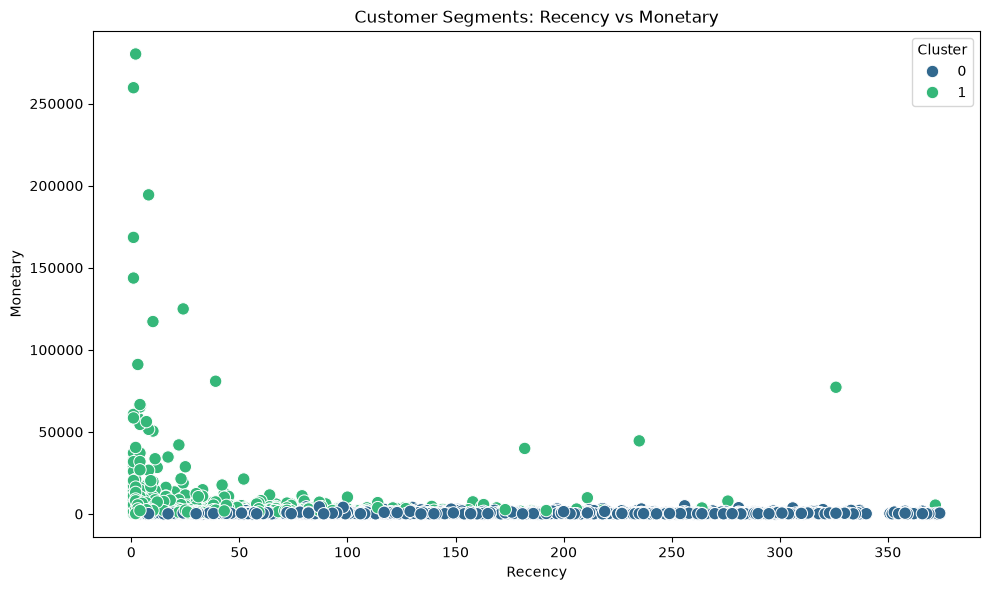

In [32]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="viridis",
    s=80
)

plt.title("Customer Segments: Recency vs Monetary")
plt.xlabel("Recency")
plt.ylabel("Monetary")

plt.tight_layout()
plt.show()

# Step 19 — Cluster Profile Heatmap

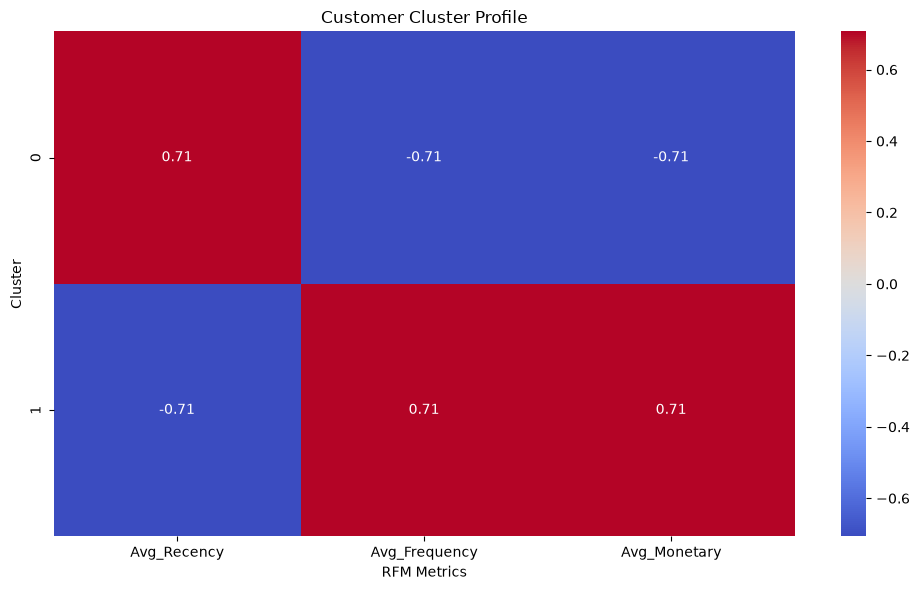

In [33]:
profile = cluster_summary[
    [
        "Avg_Recency",
        "Avg_Frequency",
        "Avg_Monetary"
    ]
].copy()

profile_scaled = (
    profile - profile.mean()
) / profile.std()

plt.figure(figsize=(10, 6))

sns.heatmap(
    profile_scaled,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Customer Cluster Profile")
plt.xlabel("RFM Metrics")
plt.ylabel("Cluster")

plt.tight_layout()
plt.show()

# Step 20 — Customer Segment Names

In [34]:
cluster_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,2672,134.09,1.67,495.59
1,1666,25.89,8.44,4539.60


In [37]:
cluster_names = {
    0: "VIP Customers",
    1: "Loyal Customers",
    2: "Potential Customers",
    3: "At-Risk Customers"
}
print(cluster_names)

{0: 'VIP Customers', 1: 'Loyal Customers', 2: 'Potential Customers', 3: 'At-Risk Customers'}


# Step 21 — Automatically Customer Segment Assign

In [38]:
cluster_names = {
    0: "VIP Customers",
    1: "Loyal Customers",
    2: "Potential Customers",
    3: "At-Risk Customers"
}

# Step 22 — Customer Segment Column

In [39]:
rfm["Customer_Segment"] = rfm["Cluster"].map(cluster_names)

In [40]:
rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,Cluster,Customer_Segment
0,12346,326,1,77183.60,1,Loyal Customers
1,12347,2,7,4310.00,1,Loyal Customers
2,12348,75,4,1797.24,1,Loyal Customers
3,12349,19,1,1757.55,0,VIP Customers
4,12350,310,1,334.40,0,VIP Customers
5,12352,36,8,2506.04,1,Loyal Customers
6,12353,204,1,89.00,0,VIP Customers
7,12354,232,1,1079.40,0,VIP Customers
8,12355,214,1,459.40,0,VIP Customers
9,12356,23,3,2811.43,1,Loyal Customers


# Step 23 — Segment-wise Summary

In [41]:
segment_summary = rfm.groupby(
    "Customer_Segment"
).agg(
    Customers=("CustomerID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).round(2)

segment_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Customer_Segment,,,,
Loyal Customers,1666,25.89,8.44,4539.60
VIP Customers,2672,134.09,1.67,495.59


# Step 24 — Segment Customer Count

In [42]:
segment_counts = (
    rfm["Customer_Segment"]
    .value_counts()
)

segment_counts

Customer_Segment
VIP Customers      2672
Loyal Customers    1666
Name: count, dtype: int64

# Visualization:

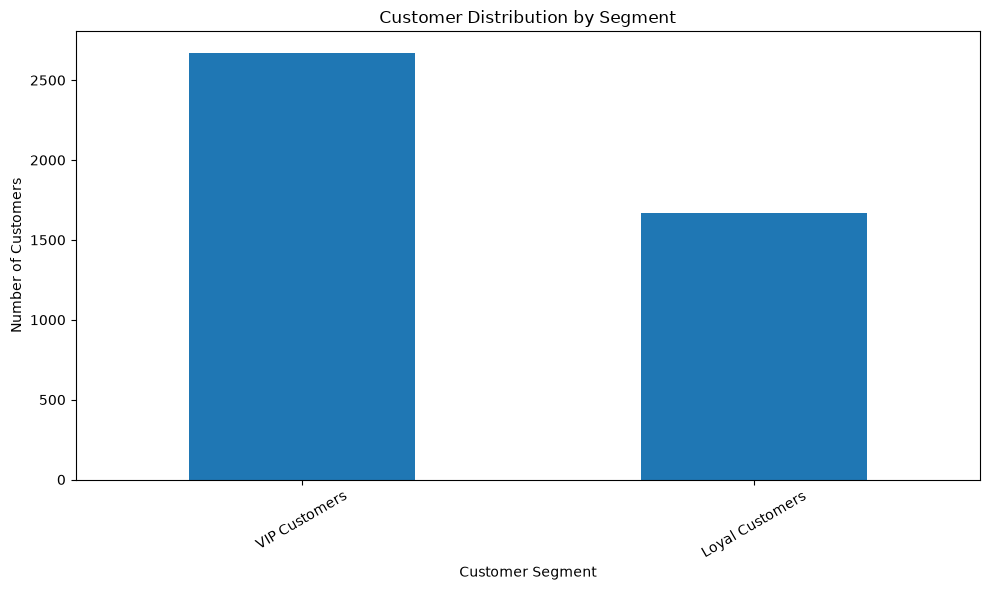

In [43]:
plt.figure(figsize=(10, 6))

segment_counts.plot(
    kind="bar"
)

plt.title("Customer Distribution by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Step 25 — Segment Revenue

In [44]:
segment_revenue = (
    rfm.groupby("Customer_Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
)

segment_revenue

Customer_Segment
Loyal Customers    7562979.201
VIP Customers      1324229.693
Name: Monetary, dtype: float64

# Chart:

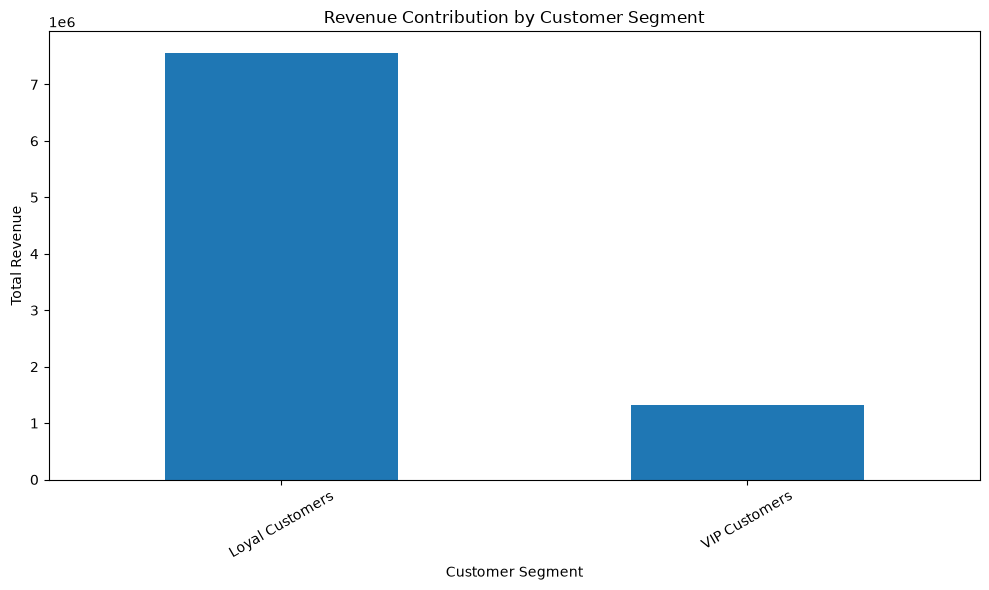

In [45]:
plt.figure(figsize=(10, 6))

segment_revenue.plot(
    kind="bar"
)

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Step 26 — Segment Percentage

In [46]:
segment_percentage = (
    segment_counts /
    segment_counts.sum() * 100
).round(2)

segment_percentage

Customer_Segment
VIP Customers      61.6
Loyal Customers    38.4
Name: count, dtype: float64

# Step 27 — Final Customer Dataset

In [47]:
final_customer_data = rfm[
    [
        "CustomerID",
        "Recency",
        "Frequency",
        "Monetary",
        "Cluster",
        "Customer_Segment"
    ]
].copy()

final_customer_data.head(10)

,CustomerID,Recency,Frequency,Monetary,Cluster,Customer_Segment
0,12346,326,1,77183.60,1,Loyal Customers
1,12347,2,7,4310.00,1,Loyal Customers
2,12348,75,4,1797.24,1,Loyal Customers
3,12349,19,1,1757.55,0,VIP Customers
4,12350,310,1,334.40,0,VIP Customers
5,12352,36,8,2506.04,1,Loyal Customers
6,12353,204,1,89.00,0,VIP Customers
7,12354,232,1,1079.40,0,VIP Customers
8,12355,214,1,459.40,0,VIP Customers
9,12356,23,3,2811.43,1,Loyal Customers


# Step 28 — Save RFM Dataset

In [54]:
final_customer_data.to_csv(
    "../data/rfm_customer_segments.csv",
    index=False
)

print("Customer segmentation data saved successfully!")

Customer segmentation data saved successfully!


# Step 29 — Save K-Means Model

In [55]:
joblib.dump(
    kmeans,
    "../models/kmeans_model.pkl"
)

print("K-Means model saved successfully!")

K-Means model saved successfully!


# Step 30 — Save Scaler

In [56]:
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("Scaler saved successfully!")

Scaler saved successfully!


# Step 31 — Final Model Verification

In [57]:
loaded_model = joblib.load(
    "../models/kmeans_model.pkl"
)

loaded_scaler = joblib.load(
    "../models/scaler.pkl"
)

print("Model loaded successfully!")
print("Scaler loaded successfully!")

Model loaded successfully!
Scaler loaded successfully!


# Step 32 — Final Project Result

In [58]:
print("=" * 60)
print("ONLINE RETAIL CUSTOMER SEGMENTATION")
print("=" * 60)

print(f"Total Customers: {rfm['CustomerID'].nunique():,}")
print(f"Number of Clusters: {optimal_k}")
print(f"Silhouette Score: {best_score:.4f}")
print(f"Total Revenue: {rfm['Monetary'].sum():,.2f}")

print("\nCustomer Segments:")
print(segment_counts)

print("\nProject completed successfully!")

ONLINE RETAIL CUSTOMER SEGMENTATION
Total Customers: 4,338
Number of Clusters: 2
Silhouette Score: 0.4328
Total Revenue: 8,887,208.89

Customer Segments:
Customer_Segment
VIP Customers      2672
Loyal Customers    1666
Name: count, dtype: int64

Project completed successfully!


In [59]:
cluster_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,2672,134.09,1.67,495.59
1,1666,25.89,8.44,4539.60
